# Gaming Industry Data - EDA

first look at the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('gaming_industry_trends.csv')
df.head()

,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
0,Neon Speed 5,Strategy,Xbox,2011,Capcom,52.28,77.99,21.44,69,No,Stable
1,Cyber Quest 5,Shooter,Mobile,2018,Bandai Namco,4345.97,65.28,11.22,72,No,Stable
2,Fantasy Rivals 1,Strategy,Xbox,2018,Microsoft,1278.29,160.09,48.40,51,Yes,Declining
3,Warzone Chronicles 5,Horror,Xbox,2002,Microsoft,361.26,98.14,32.96,91,No,Declining
4,Cyber Quest 4,RPG,PC,2018,EA,4549.27,199.47,58.39,74,No,Stable


In [3]:
print('rows:', df.shape[0])
print('columns:', df.shape[1])

rows: 1000
columns: 11


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               1000 non-null   str    
 1   Genre                    1000 non-null   str    
 2   Platform                 1000 non-null   str    
 3   Release Year             1000 non-null   int64  
 4   Developer                1000 non-null   str    
 5   Revenue (Millions $)     1000 non-null   float64
 6   Players (Millions)       1000 non-null   float64
 7   Peak Concurrent Players  1000 non-null   float64
 8   Metacritic Score         1000 non-null   int64  
 9   Esports Popularity       1000 non-null   str    
 10  Trending Status          1000 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 86.1 KB


In [28]:
# column names have spaces
df.columns.tolist()

['Game Title',
 'Genre',
 'Platform',
 'Release Year',
 'Developer',
 'Revenue (Millions $)',
 'Players (Millions)',
 'Peak Concurrent Players',
 'Metacritic Score',
 'Esports Popularity',
 'Trending Status']

In [29]:
# quick look at revenue stats
df['Revenue'].describe()

KeyError: 'Revenue'

## missing values

In [30]:
df.isnull().sum()

Game Title                 0
Genre                      0
Platform                   0
Release Year               0
Developer                  0
Revenue (Millions $)       0
Players (Millions)         0
Peak Concurrent Players    0
Metacritic Score           0
Esports Popularity         0
Trending Status            0
dtype: int64

In [31]:
print('duplicate rows:', df.duplicated().sum())

duplicate rows: 0


## basic stats

In [32]:
df.describe()

,Release Year,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2012.074000,2483.017800,103.499820,31.602150,74.990000
std,7.031356,1412.629451,58.869562,23.023375,14.618536
min,2000.000000,11.430000,0.530000,0.110000,50.000000
25%,2006.000000,1276.190000,52.005000,12.967500,62.000000
50%,2012.000000,2476.130000,107.040000,26.405000,76.000000
75%,2018.000000,3677.797500,155.632500,46.020000,87.000000
max,2024.000000,4999.790000,199.980000,96.620000,100.000000


## genres

In [33]:
genre_counts = df['Genre'].value_counts()
print(genre_counts)

Genre
Action        122
Strategy      116
Sports        116
Fighting      103
Shooter       100
Horror         96
Racing         95
Adventure      87
Simulation     87
RPG            78
Name: count, dtype: int64


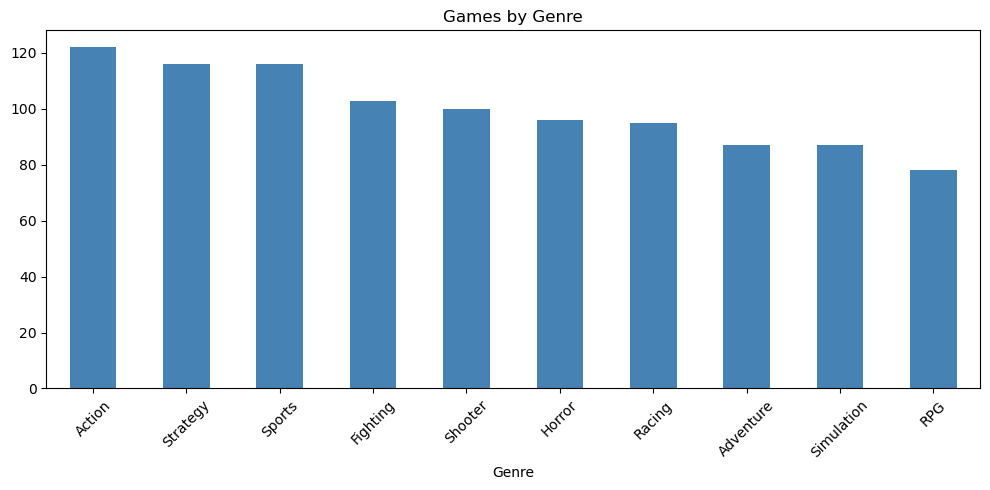

In [34]:
plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar', color='steelblue')
plt.title('Games by Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## platforms

In [35]:
df['Platform'].value_counts()

Platform
PlayStation        175
PC                 174
Cross-Platform     168
Xbox               167
Mobile             158
Nintendo Switch    158
Name: count, dtype: int64

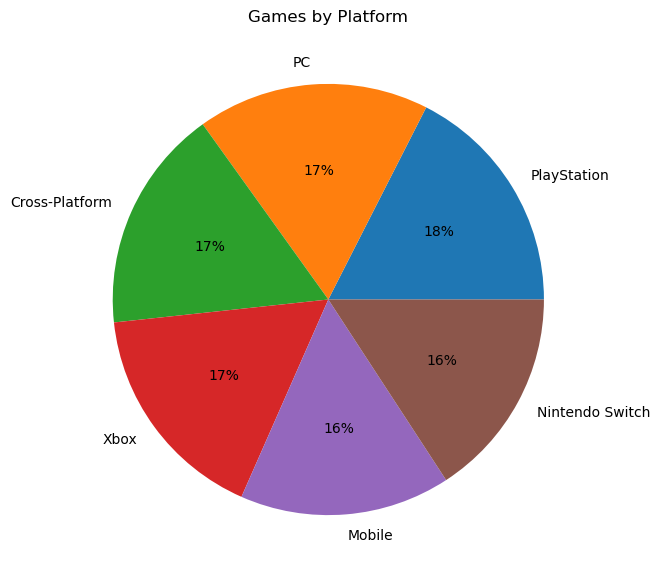

In [36]:
df['Platform'].value_counts().plot(kind='pie', figsize=(7, 7), autopct='%1.0f%%')
plt.title('Games by Platform')
plt.show()

## revenue

In [37]:
print(df['Revenue (Millions $)'].describe())

count    1000.000000
mean     2483.017800
std      1412.629451
min        11.430000
25%      1276.190000
50%      2476.130000
75%      3677.797500
max      4999.790000
Name: Revenue (Millions $), dtype: float64


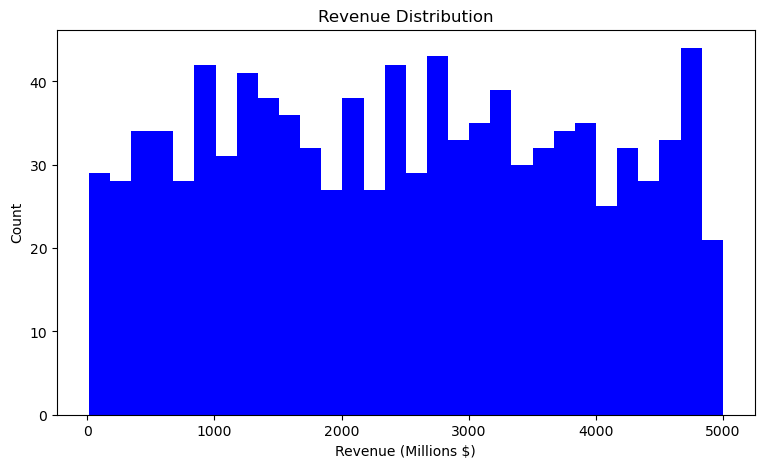

In [38]:
plt.figure(figsize=(9, 5))
plt.hist(df['Revenue (Millions $)'], bins=30, color='blue')
plt.title('Revenue Distribution')
plt.xlabel('Revenue (Millions $)')
plt.ylabel('Count')
plt.show()

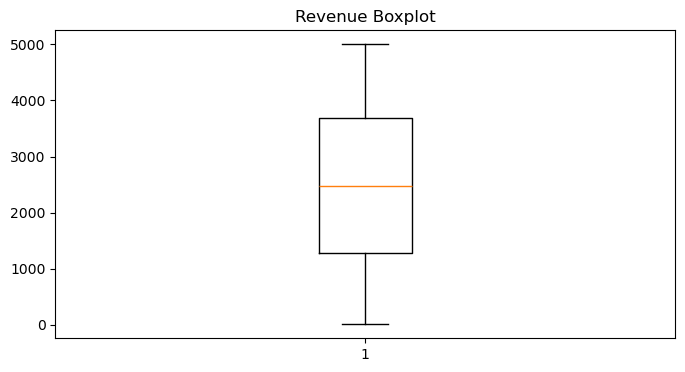

In [39]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['Revenue (Millions $)'])
plt.title('Revenue Boxplot')
plt.show()

In [40]:
genre_revenue = df.groupby('Genre')['Revenue (Millions $)'].mean().sort_values(ascending=False)
print(genre_revenue)

Genre
RPG           2716.126026
Fighting      2649.903786
Simulation    2554.510460
Horror        2524.360104
Adventure     2501.954598
Racing        2460.275263
Strategy      2439.547759
Shooter       2428.929300
Action        2388.327213
Sports        2284.364741
Name: Revenue (Millions $), dtype: float64


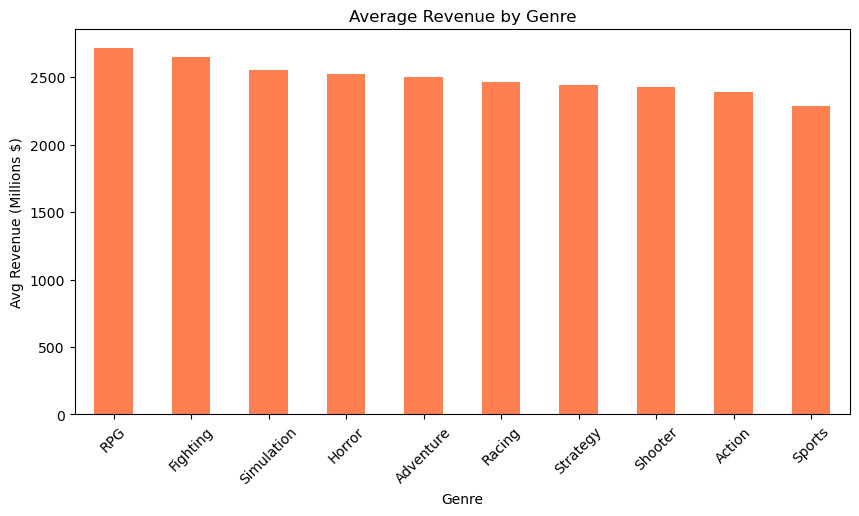

In [41]:
plt.figure(figsize=(10, 5))
genre_revenue.plot(kind='bar', color='coral')
plt.title('Average Revenue by Genre')
plt.ylabel('Avg Revenue (Millions $)')
plt.xticks(rotation=45)
plt.show()

## metacritic scores

In [42]:
df['Metacritic Score'].describe()

count    1000.000000
mean       74.990000
std        14.618536
min        50.000000
25%        62.000000
50%        76.000000
75%        87.000000
max       100.000000
Name: Metacritic Score, dtype: float64

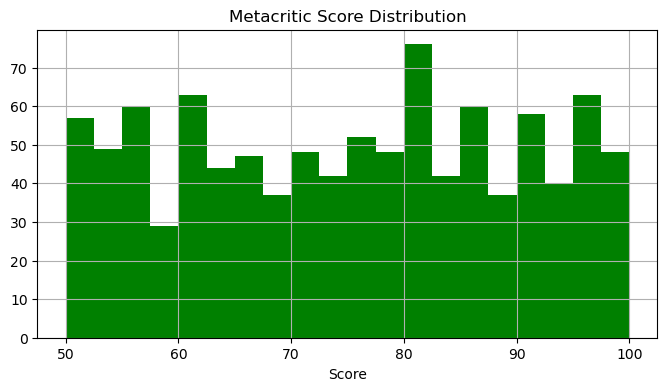

In [43]:
df['Metacritic Score'].hist(bins=20, figsize=(8, 4), color='green')
plt.title('Metacritic Score Distribution')
plt.xlabel('Score')
plt.show()

## score vs revenue

curious if higher rated games make more money

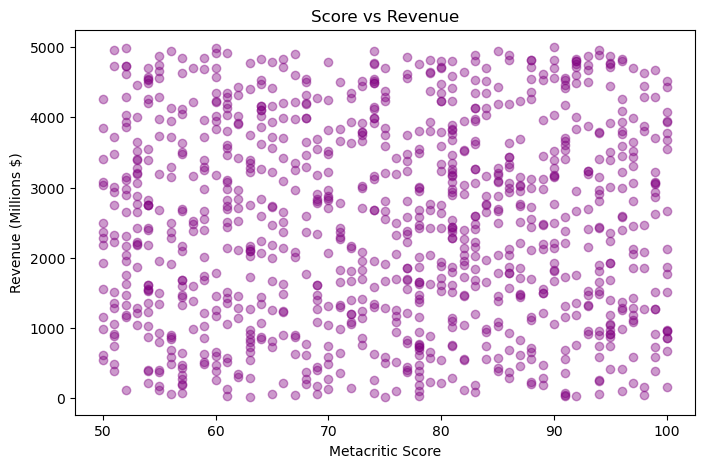

In [44]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Metacritic Score'], df['Revenue (Millions $)'], alpha=0.4, color='purple')
plt.xlabel('Metacritic Score')
plt.ylabel('Revenue (Millions $)')
plt.title('Score vs Revenue')
plt.show()

In [45]:
corr = df['Metacritic Score'].corr(df['Revenue (Millions $)'])
print('correlation score vs revenue:', round(corr, 2))

correlation score vs revenue: 0.02


## top developers

In [ ]:
top_devs = df['Developer'].value_counts().head(10)
top_devs

In [ ]:
top_devs.plot(kind='barh', figsize=(8, 5), color='teal')
plt.title('Top 10 Developers by Game Count')
plt.xlabel('Number of Games')
plt.show()

## esports popularity

In [ ]:
df['Esports Popularity'].value_counts()

In [ ]:
esports_yes = df[df['Esports Popularity'] == 'Yes']['Revenue (Millions $)'].mean()
esports_no = df[df['Esports Popularity'] == 'No']['Revenue (Millions $)'].mean()

print('avg revenue - esports:', round(esports_yes, 2))
print('avg revenue - non esports:', round(esports_no, 2))

In [ ]:
# how big is the difference
print('revenue difference:', round(rev_diff, 2))

In [ ]:
# score comparison too
print('avg score - esports:', round(df[df['Esports Popularity'] == 'Yes']['Metacritic Score'].mean(), 2))
print('avg score - non esports:', round(df[df['Esports Popularity'] == 'No']['Metacritic Score'].mean(), 2))

## games per year

In [ ]:
year_counts = df['Release Year'].value_counts().sort_index()
year_counts

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(year_counts.index, year_counts.values, marker='o', color='darkblue')
plt.title('Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## trending status

In [ ]:
df['Trending Status'].value_counts()

In [ ]:
df['Trending Status'].value_counts().plot(kind='bar', figsize=(7, 4), color='orange')
plt.title('Trending Status')
plt.xticks(rotation=0)
plt.show()